# 时光旅行
- 时光旅行允许用户回溯和修改过去的状态
- 重放是对过去状态的重播
- 分叉则允许重新访问智能体的过去操作并探索图中的替代路径

## 一、重放

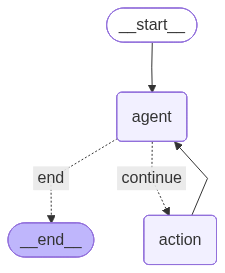

In [2]:
from model_factory import MiniMax_Model
from langchain_core.tools import tool
from langgraph.graph import StateGraph,START,END,MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import Image,display

@tool
def play_song_on_qq(song:str) ->str:
    '''
    用qq音乐放歌
    :param song:
    :return:
    '''
    return f"成功在qq音乐上播放了{song}"

@tool
def play_song_on_netease(song:str)->str:
    '''
    应用网易云音乐放个
    :param song:
    :return:
    '''
    return f"成功在网易云音乐上播放了{song}"

tools = [play_song_on_qq,play_song_on_netease]
tool_node = ToolNode(tools)

model = MiniMax_Model.bind_tools(tools=tools,parallel_tool_calls=False)

def should_continue(state:MessagesState)->str:
    messages = state["messages"]
    last_message = messages[-1]

    if not last_message.tool_calls:
        return "end"
    else:
        return "continue"

def call_llm(state:MessagesState)->dict:
    messages = state["messages"]
    response = model.invoke( messages)
    return {
        "messages":[response]
    }


workflow_builder = StateGraph(MessagesState)
workflow_builder.add_node("action",tool_node)
workflow_builder.add_node("agent",call_llm)

workflow_builder.add_edge(START,"agent")
workflow_builder.add_conditional_edges(
    "agent",
    should_continue,
    {
        "continue":"action",
        "end":END
    }
)
workflow_builder.add_edge("action","agent")

memory = MemorySaver()

app = workflow_builder.compile(checkpointer=memory)

display(Image(app.get_graph().draw_mermaid_png()))

In [3]:
input = {
    "messages":[
        {"role":"user","content":"你能播放听一首歌,你来选"},
    ]
}

config = {
    "configurable":{
        "thread_id":"1"
    }
}

for event in app.stream(input=input,config=config,stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

你能播放听一首歌,你来选
================================== Ai Message ==================================



，那我给你放一首周杰伦的《晴天》吧，非常经典的一首歌！🎵
Tool Calls:
  play_song_on_netease (019dd859610f80af951ea50f7f610910)
 Call ID: 019dd859610f80af951ea50f7f610910
  Args:
    song: 晴天 周杰伦
================================= Tool Message =================================
Name: play_song_on_netease

成功在网易云音乐上播放了晴天 周杰伦
================================== Ai Message ==================================



好啦！已经为你播放了周杰伦的《晴天》，希望你喜欢～ 🎶

这首歌是周杰伦非常经典的代表作之一，旋律优美，歌词也很感人。如果你还想听别的歌曲，告诉我歌名或者歌手，我来帮你播放！


### 重放

In [4]:
all_states = []

for sate in app.get_state_history(config=config):
    print(sate)
    all_states.append(sate)
    print("--------")

StateSnapshot(values={'messages': [HumanMessage(content='你能播放听一首歌,你来选', additional_kwargs={}, response_metadata={}, id='328ebb24-ca42-466f-a220-6f5fb1e241a3'), AIMessage(content='\n\n，那我给你放一首周杰伦的《晴天》吧，非常经典的一首歌！🎵\n', additional_kwargs={}, response_metadata={'finish_reason': 'tool_calls', 'model_name': 'Pro/MiniMaxAI/MiniMax-M2.5', 'model_provider': 'openai'}, id='lc_run--019dd859-5856-7ec0-9bc1-2fdf01d7783a', tool_calls=[{'name': 'play_song_on_netease', 'args': {'song': '晴天 周杰伦'}, 'id': '019dd859610f80af951ea50f7f610910', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 29256, 'output_tokens': 5682, 'total_tokens': 34938, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 5312}}), ToolMessage(content='成功在网易云音乐上播放了晴天 周杰伦', name='play_song_on_netease', id='2a64c425-8373-44e8-ba10-5314be5cd293', tool_call_id='019dd859610f80af951ea50f7f610910'), AIMessage(content='\n\n好啦！已经为你播放了周杰伦的《晴天》，希望你喜欢～ 🎶\n\n这首歌是周杰伦非常经典的代表作之一，旋律优美，歌词也很感人。如果你还想

In [5]:
# 返回到任意一个节点,并从那里重新开始操作
to_replay = all_states[2]
to_replay.values
to_replay.next

for event in app.stream(input=None,config=to_replay.config):
    for v in event.values():
        print(v)

{'messages': [ToolMessage(content='成功在网易云音乐上播放了晴天 周杰伦', name='play_song_on_netease', id='a6918ba4-e6fe-428f-892e-fd088e69a1c6', tool_call_id='019dd859610f80af951ea50f7f610910')]}
{'messages': [AIMessage(content='\n\n已经为你播放了周杰伦的《晴天》🎶 这首歌真的很好听，经典的旋律百听不厌！希望你喜欢这首歌～\n\n如果你想听其他歌曲，随时告诉我哦！😊', additional_kwargs={}, response_metadata={'finish_reason': 'stop', 'model_name': 'Pro/MiniMaxAI/MiniMax-M2.5', 'model_provider': 'openai'}, id='lc_run--019dd859-6706-7c31-bc5e-4b5cfa3c719f', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 22464, 'output_tokens': 2085, 'total_tokens': 24549, 'input_token_details': {'cache_read': 20160}, 'output_token_details': {'reasoning': 1196}})]}


## 二、分支
从某个节点开始操作,对执行数据进行分叉

In [7]:
# 修改最后一个消息的工具调用
# 我们将从play song on qq 更改为 play song on netease
last_message = to_replay.values["messages"][-1]
last_message.tool_calls[0]["name"] = "play_song_on_netease"

bruch_config = app.update_state(
    to_replay.config,
    {"messages":[last_message]}
)


### 此时整个图的流就进行了分叉处理

In [9]:
for event in app.stream(None,config=bruch_config):
    for v in event.values():
        print(v)

{'messages': [ToolMessage(content='成功在网易云音乐上播放了晴天 周杰伦', name='play_song_on_netease', id='82d3456d-ac87-4304-8ddc-7e0d953d059a', tool_call_id='019dd859610f80af951ea50f7f610910')]}
{'messages': [AIMessage(content='\n\n已经为你播放了周杰伦的《晴天》！🎶\n\n希望你喜欢这首经典的老歌~ 如果想听别的风格或者特定歌手的歌，随时告诉我！😊', additional_kwargs={}, response_metadata={'finish_reason': 'stop', 'model_name': 'Pro/MiniMaxAI/MiniMax-M2.5', 'model_provider': 'openai'}, id='lc_run--019dd85b-4066-7c62-b2de-ad071cb041d6', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 24570, 'output_tokens': 2471, 'total_tokens': 27041, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 1820}})]}
